## `plot_crosscorr.py`

In [52]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cmocean.cm as cmo

from pathlib import Path
from pycorr import TwoPointCorrelationFunction, utils, TwoPointEstimator

import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct
import importlib

cmap = cmo.thermal

/tmp/ipykernel_548188/3391515458.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


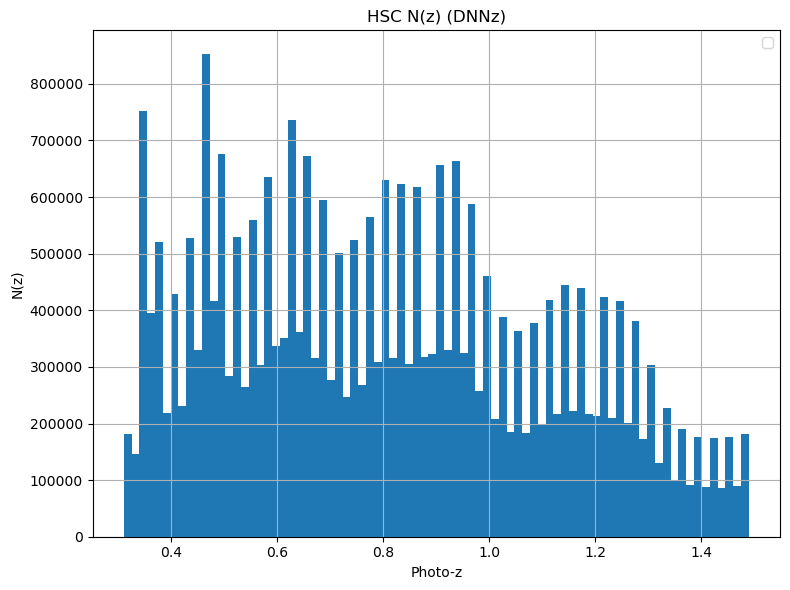

In [54]:
bins = np.arange(0.3, 1.8, 0.3) #LRG
tgt_file = cf.fetch_hsc_files(sims_version=0)
tbl = fio.FITS(tgt_file)[1].read()

photoz = tbl['dnnz_photoz_best']

cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8, 6))

plt.hist(
    photoz[(photoz > 0.3) & (photoz < 1.5)], 
    bins=80,
)

ax.set_xlabel('Photo-z')
ax.set_ylabel('N(z)')
ax.set_title('HSC N(z) (DNNz)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

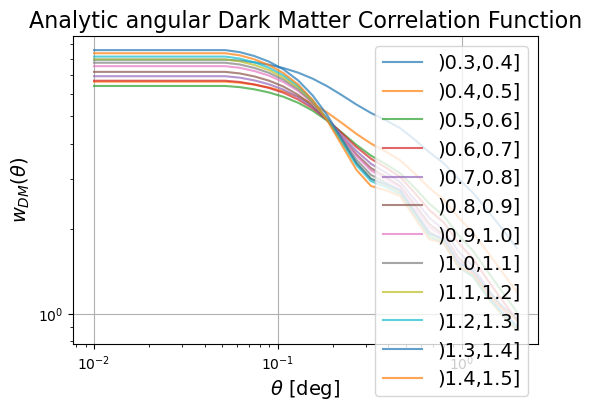

In [3]:
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# We use: ΩDM = 0.258868, Ωb = 0.048252, ℎ = 0.6777, 𝑛𝑠 = 0.95 and 𝜎8 = 0.8.
cosmo = ccl.Cosmology(
    Omega_c=0.258868, Omega_b=0.048252, h=0.6777, sigma8=0.8, n_s=0.95
)
for j, nz in enumerate(nzs, 1):
    tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z[1:], nz), bias=(z[1:], 0.95/(1/(1 + z[1:]))))

    # 4. Compute angular power spectrum C_ell
    ell = np.arange(0.1, 10000, 0.1)
    cl = ccl.angular_cl(cosmo, tracer, tracer, ell)

    # 5. Transform to w(theta) using Legendre series
    theta = np.logspace(-2, 0.3, 30)  # theta in degrees
    theta_rad = np.deg2rad(theta)
    wtheta = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_rad)

    plt.loglog(theta, wtheta, label=f'){bins[j-1]:.1f},{bins[j]:.1f}]', alpha=0.7)

plt.xlabel(r'$\theta$ [deg]', fontsize=14)
plt.ylabel(r'$w_{DM}(\theta)$', fontsize=14)
plt.title('Analytic angular Dark Matter Correlation Function', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)

v3 : 24.5 cut
v5 : 24.5 cut + downsample

In [6]:
importlib.reload(cf)
file_reader_xcorr = cf.CorrFileReader('../outputs/results_sims/cross_j64_ns256_zbin')

In [23]:
tgt1 = 'ELGnotqso'
tgt2 = 'HSC'
moc_idx = 0

In [24]:
importlib.reload(ct)
file_reader_xcorr.make_dndz(sims=0, overwrite=True)

Using real data
Processing ELGnotqso...
Processing LRG...
Processing QSO...
Processing BGS_ANY...
Processing HSC...


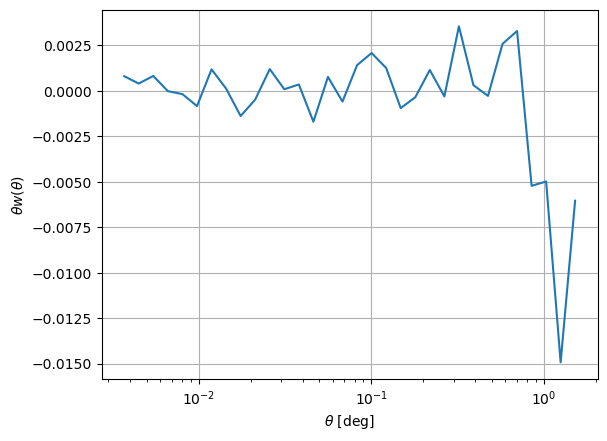

In [18]:
res = TwoPointEstimator.load(file_reader_xcorr.get_file(1, 2, tgt1=tgt1, tgt2=tgt2, moc=0))
res.plot()
plt.xscale('log')

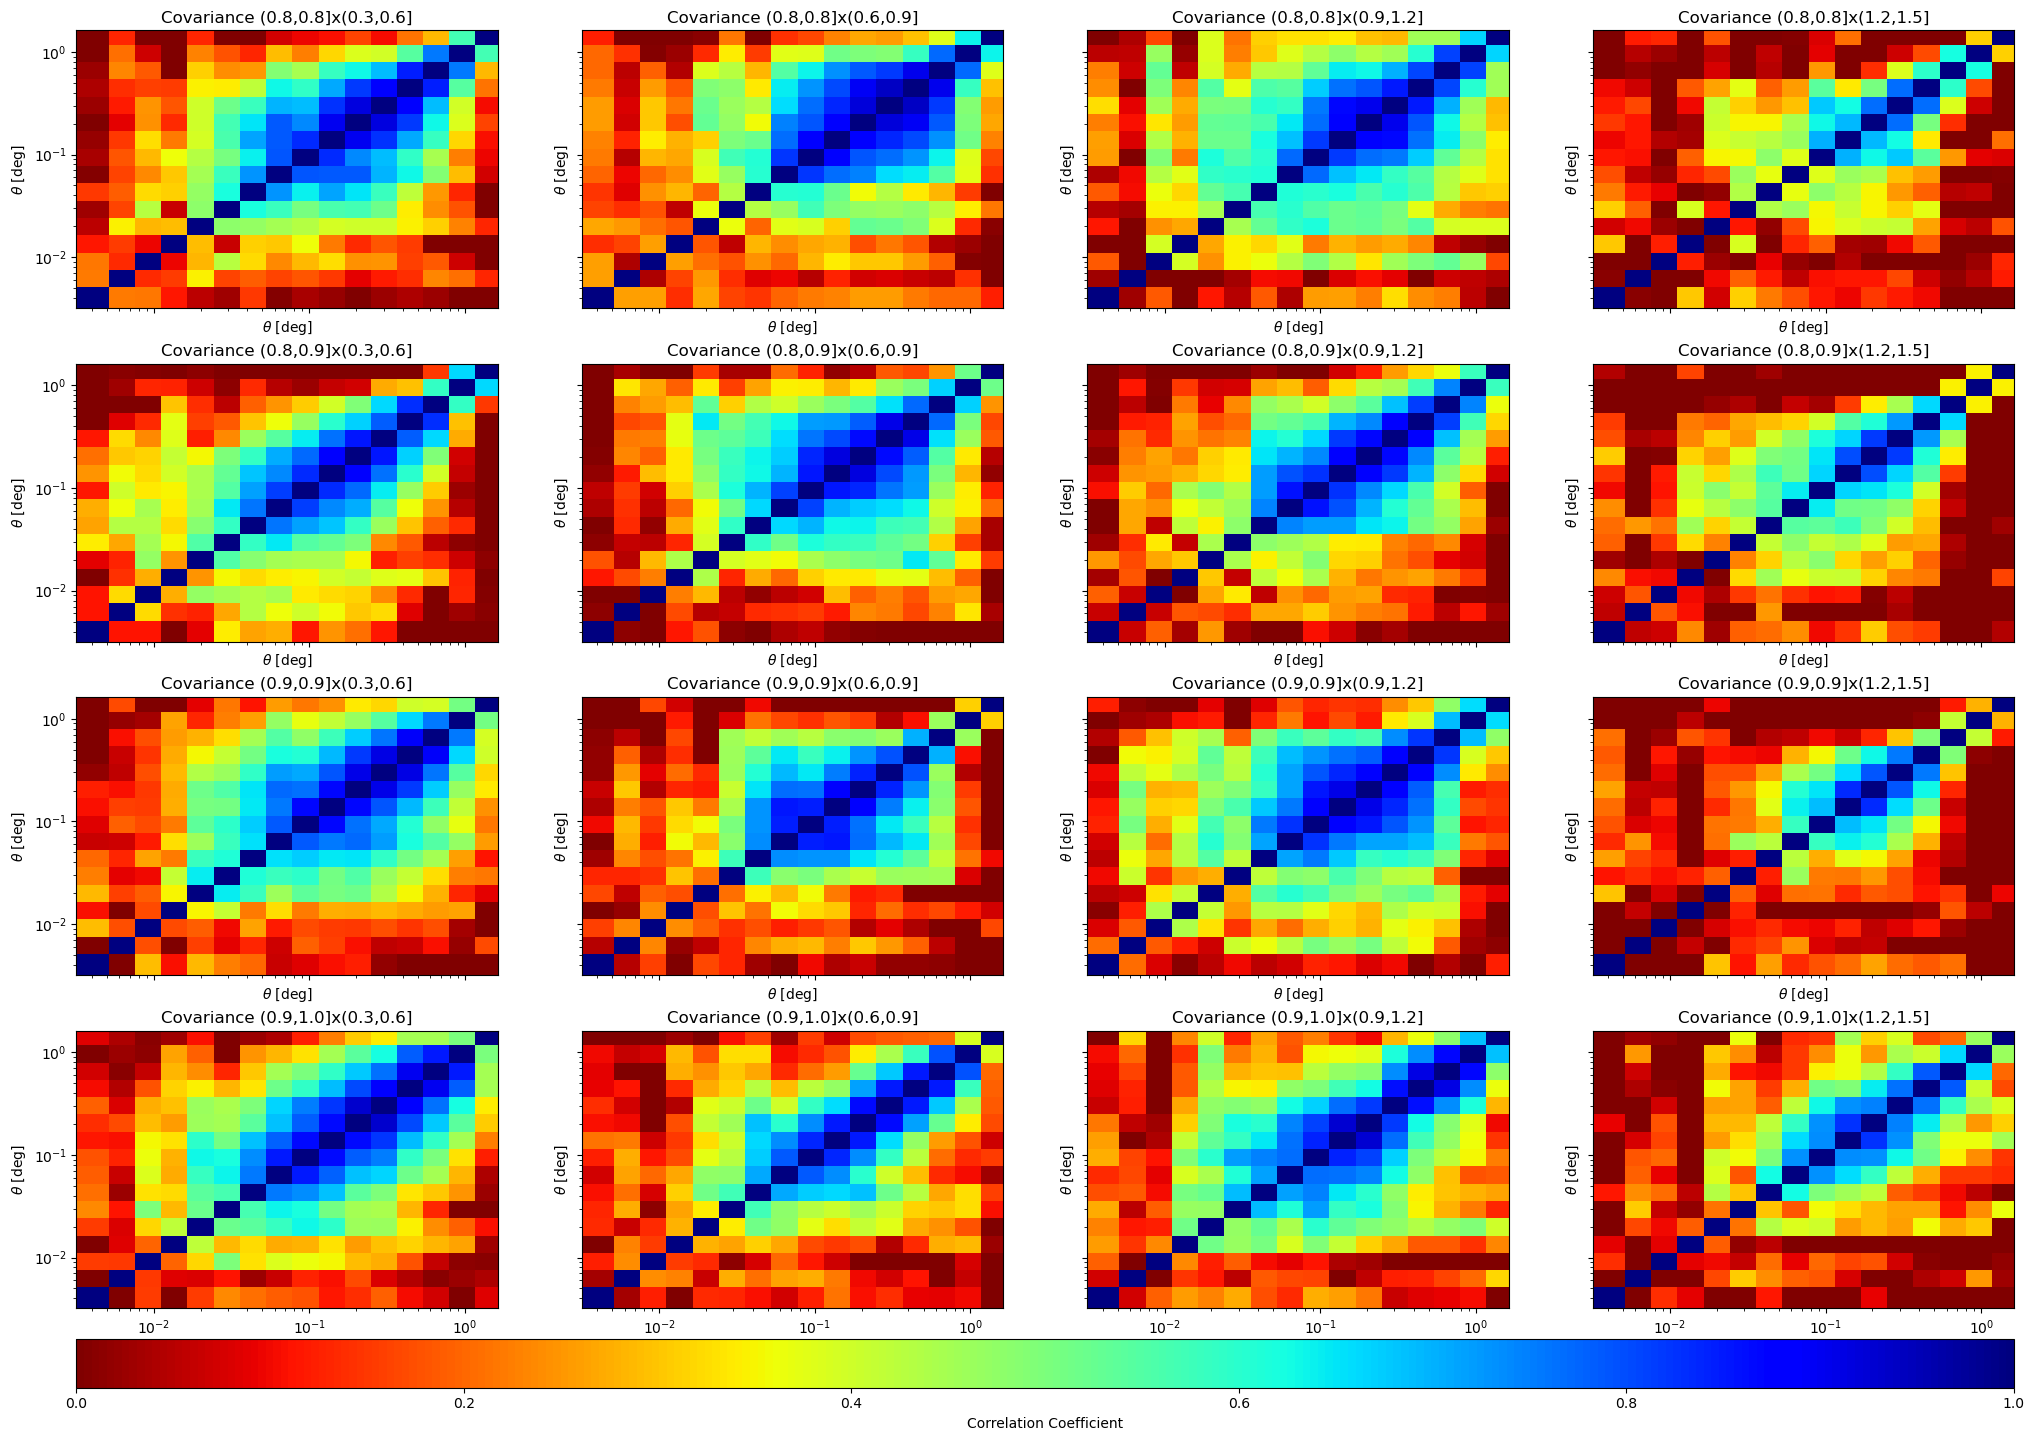

In [35]:
fig, axs = plt.subplots(4, 4, figsize=(25, 20), sharex=True, sharey=True)
bins_tgt1 = file_reader_xcorr.get_bins(tgt1)
bins_tgt2 = file_reader_xcorr.get_bins(tgt2)

for i in range(1, len(bins_tgt1)):
    for j in range(1, len(bins_tgt2)):
        try:
            result = TwoPointEstimator.load(
                file_reader_xcorr.get_file(i, j, tgt1, tgt2, moc_idx)
                )
            result.rebin(2)
        except FileNotFoundError:
            continue
        try:
            ax = axs[i-1, j-1]
        except IndexError:
            continue
        sep = result.sep
        cov = result.cov()

        corrcoef = utils.cov_to_corrcoef(result.cov())

        ax.pcolor(sep, sep, corrcoef.T, cmap=plt.get_cmap('jet_r'), vmin=0, vmax=1)
        ax.set_title(f'Covariance ({bins_tgt1[i-1]:.1f},{bins_tgt1[i]:.1f}]x({bins_tgt2[j-1]:.1f},{bins_tgt2[j]:.1f}]')
        ax.set_xlabel(r'$\theta$ [deg]')
        ax.set_ylabel(r'$\theta$ [deg]')
        ax.set_xscale('log')
        ax.set_yscale('log')

# Add a single colorbar for all subplots
cbar = fig.colorbar(
    axs[0, 0].collections[0], 
    ax=axs, 
    label="Correlation Coefficient", 
    orientation='horizontal', 
    pad=0.02, 
    aspect=40
    )

plt.show()

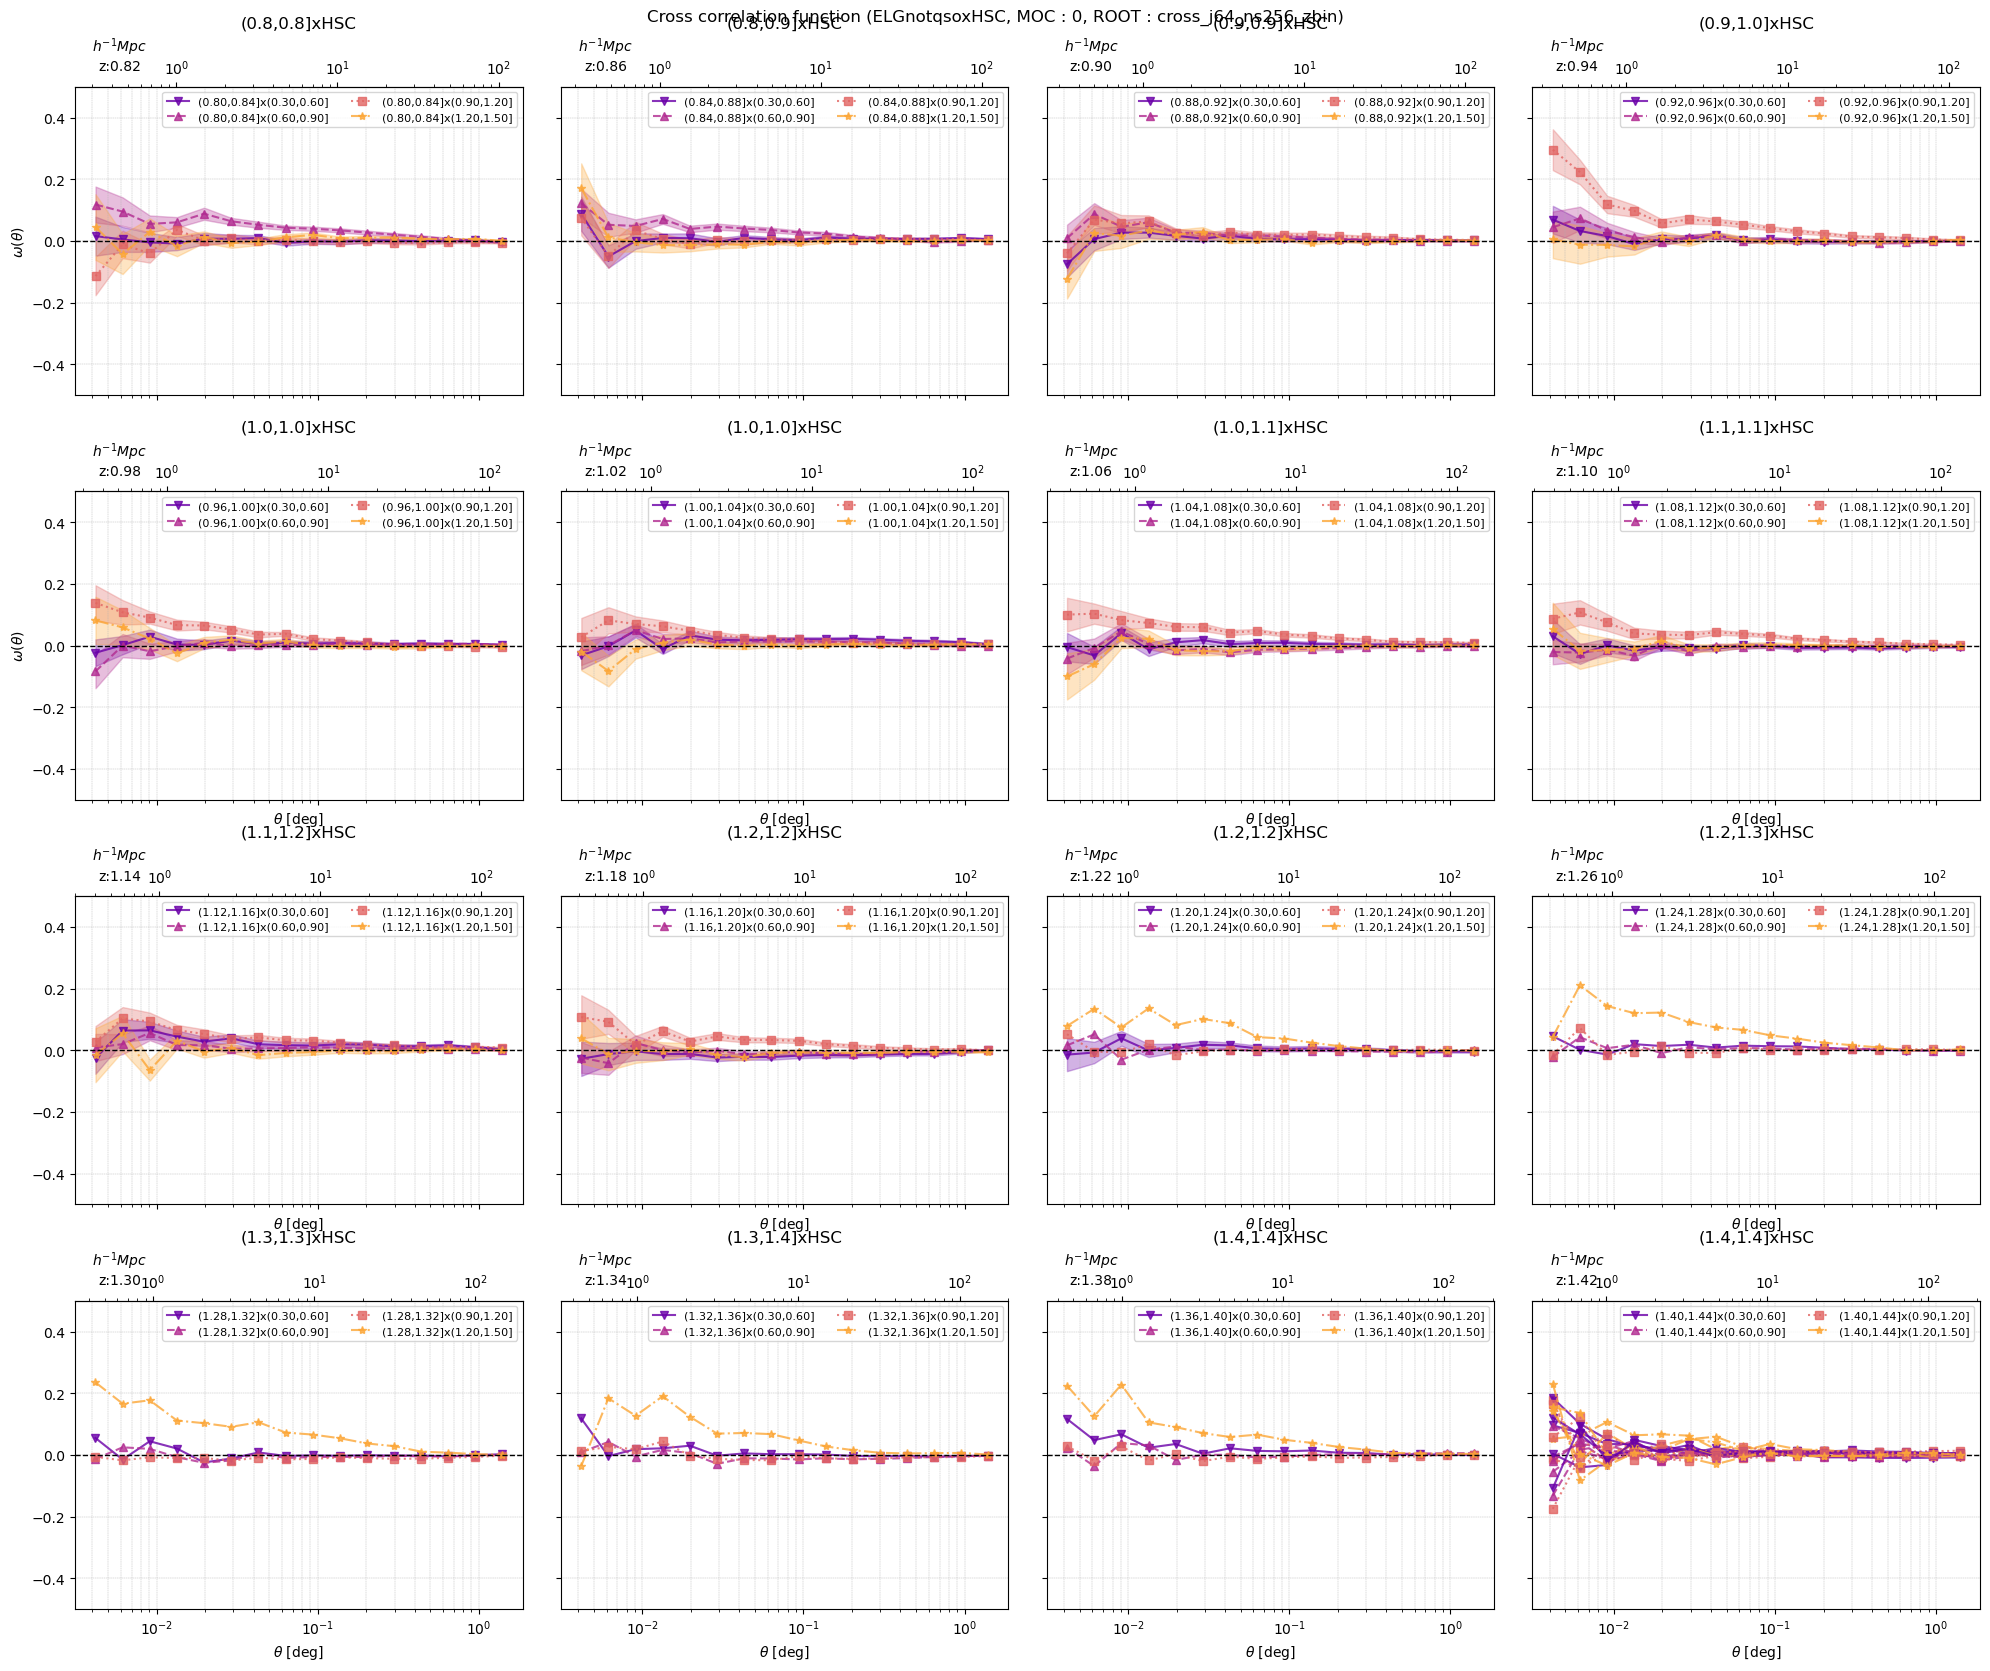

In [40]:
importlib.reload(cf)
#file_reader = cu.CorrFileReader('../crosscorr/corr23bgs/')
sepmult = False
mode = 'theta' # can also be 'rp'
normalize_by_dndz = False
rebin=2
# (2, 4) for ELGnotqso
# (2, 4) for LRG (remove last)
# (1, 4) for QSO
nrows = 4
ncols = 4
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5), sharex=True, sharey=True)
bins_tgt1 = file_reader_xcorr.get_bins(tgt1)
bins_tgt2 = file_reader_xcorr.get_bins(tgt2)
axs = axs.flatten()
plasma = plt.get_cmap('plasma')

if normalize_by_dndz:
    dndz_tgt1 = file_reader_xcorr.get_dndz(tgt=tgt1)
    dndz_tgt2 = file_reader_xcorr.get_dndz(tgt=tgt2)

exit_plot = False
for i in range(1, len(bins_tgt1)):
    for j in range(1, len(bins_tgt2)):
        nocov = False
        try:
            ax = axs[i-1]
        except IndexError:
            exit_plot = True
        try:
            cov_result = TwoPointCorrelationFunction.load(
                file_reader_xcorr.get_file(i, j, tgt1, tgt2, moc_idx)
                )
            cov_result = cov_result.normalize(wnorm=1)
            if rebin > 1:
                cov_result.rebin(rebin)
        except FileNotFoundError:
            #print(f'File not found for {i}, {j}')
            continue
        
        # Define bin edges
        btgt_min, btgt_max = bins_tgt1[i-1], bins_tgt1[i]
        bhsc_min, bhsc_max = bins_tgt2[j-1], bins_tgt2[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min+1e-5 and bhsc_max >= btgt_max-1e-5 :
            #color = 'blue'  # Full overlap
            pass
        elif bhsc_max <= btgt_min+1e-5  or bhsc_min >= btgt_max-1e-5 :
            #color = plasma(j/len(bins_hsc))   # No overlap
            pass
        else:
            #color = 'black' # Partial overlap
            pass
        
        color = plasma(j/len(bins_tgt2))

        ls = '-' 
        mark = 'v'
        if j == 2:
            ls = '--'
            mark = '^'
        if j == 3:
            ls = ':'
            mark = 's'
        if j == 4:
            ls = '-.'
            mark = '*'

        sep = cov_result.sep
        try:
            cov = cov_result.cov()
            jackerr = np.sqrt(np.diag(cov))
        except AttributeError:
            nocov = True
            pass

        normalization = 1
        if normalize_by_dndz:
            normalization = np.sqrt(dndz_tgt1[i-1]*dndz_tgt2[j-1])
            pass 
        sepm = (cov_result.sep if sepmult else 1)
        if not nocov:
            ax.fill_between(
                cov_result.sep,
                sepm*(cov_result.corr-jackerr)/normalization,
                sepm*(cov_result.corr+jackerr)/normalization,
                color=color,
                alpha=0.3
            )
        ax.plot(
            cov_result.sep,
            sepm*cov_result.corr/normalization,
            mark,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt1[i-1]:.2f},{bins_tgt1[i]:.2f}]x({bins_tgt2[j-1]:.2f},{bins_tgt2[j]:.2f}]'
        )
    if not exit_plot:
        if i > 4:
            if mode == 'theta':    
                ax.set_xlabel(r'$\theta$ [deg]')
            elif mode == 'rp':
                ax.set_xlabel(r'$r_p$ [Mpc/h]')
        if i == 1 or i == 5:
            if mode == 'theta':    
                ax.set_ylabel(r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$')
            elif mode == 'rp':
                ax.set_ylabel(r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$')

        ax.grid(True, which='both', linestyle='--', lw=0.3)
        ax.set_xscale('log')
        ax.axhline(0, color='k', linestyle='--', lw=1)
        ax.set_title(f'({bins_tgt1[i-1]:.1f},{bins_tgt1[i]:.1f}]x{tgt2}', fontsize=12)
        ax.legend(loc='upper right', fontsize=8, ncols=2)
        # ax.set_yscale('log')

        mid_z = (bins_tgt1[i-1] + bins_tgt1[i]) / 2
        tohMpc = lambda theta, z=mid_z: ct.arcsec2hMpc(theta * 3600, z=z)
        toArcsec = lambda x, z=mid_z: ct.hMpc2arcsec(x, z=z) / 3600

        if mode == 'theta':
            secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
            secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
            #secax.set_xscale('linear')
            secax.xaxis.set_label_coords(0.1, 0)

        if tgt1 == 'LRG' and not sepmult and mode == 'theta':
            #ax.set_ylim(-0.03, 0.163)
            pass
        if tgt1 == 'ELGnotqso' and not sepmult and mode == 'theta':
            ax.set_ylim(-0.5, 0.5)
            pass

        #ax.set_ylim(0.0001, 1)

fig.suptitle(
    f'Cross correlation function ({tgt1}x{tgt2}, MOC : {moc_idx}, ROOT : {Path(file_reader_xcorr.ROOT).stem})',
    fontsize=12
    )
fig.tight_layout()

plt.subplots_adjust(bottom=0.18)
plt.show()

In [43]:
file = '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/PIP/'
file = list(Path(file).glob('*.fits'))[0]
tbl = fio.FITS(file)[1].read()

In [22]:
## plotting autocorrelation
importlib.reload(cf)
importlib.reload(ct)

<module 'src.statistics.cosmotools' from '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/src/statistics/cosmotools.py'>

In [7]:
tgt = 'LRG'
#tgt = 'LRG'
#from : https://arxiv.org/pdf/2404.03000 (Table 4 : linear bias)
tracer_bias = {
    'LRG': 2,
    'ELGnotqso': 1.2,
    'QSO': 2.1,
    'BGS_ANY': 1.5,
    'HSC' : 1,
}

dicts_files = {
    f'{tgt} "LRG PIP" ' : '../results/autos_j64_ns256_NGC', #auto12_nonKP_FKP
    #f'{tgt} sims v5' : '../auto/small_hsc_j_v5/',
    #f'{tgt} sims v5': '../auto/auto4_sims_v5/'
}
file_readers = [cf.CorrFileReader(d) for d in dicts_files.values()]
plot_labels = list(dicts_files.keys())

moc_idx = 0
rate = 100
val_hline = tracer_bias[tgt]

In [24]:
z_resol = np.arange(0, 5, 0.1)
file_readers[0].make_dndz(sims=0, overwrite=True, oversample_rate=rate, z_dens_resolution=z_resol)
#file_readers[1].make_dndz(sims=5, overwrite=True, oversample_rate=rate, z_dens_resolution=z_resol)
#file_readers[2].make_dndz(sims=5, overwrite=True, oversample_rate=rate)
#file_readers[2].make_dndz(sims=5, overwrite=True, oversample_rate=rate)

Using real data
Processing ELGnotqso...
Processing LRG...
Processing QSO...
Processing BGS_ANY...
Processing HSC...


In [8]:
## autocorrelation settings
compare_flags = [True] * len(file_readers)
rebin = 2
plasma = plt.get_cmap('plasma')
colors = [
    plasma(i/len(file_readers)) for i in range(len(file_readers))
    ]
linestyles = ['-', '-.', '--', ':']
markers = ['v', '+', '*', '^']

sepmult = False
mode = 'theta'
normalize_by_dndz = False
normalize_by_wDM = False
assert not (normalize_by_dndz and normalize_by_wDM), 'Cannot normalize by dN/dz and bias at the same time'
bins_tgt = file_readers[0].get_bins(tgt)
print(f'Bins for {tgt}: {bins_tgt}')
nocov = False

# Try loading dN/dz for all readers
if normalize_by_dndz:
    dndz_list = []
    for i, fr in enumerate(file_readers):
        dndz = fr.get_dndz(tgt)
        dndz_list.append(dndz)
if normalize_by_wDM:
    wDM_list = []
    for i, fr in enumerate(file_readers):
        wDM = fr.get_dndz(tgt, get='wDM')
        ang_bins = fr.get_bins('theta')
        from scipy.interpolate import interp1d
        oversamp_ang_bins = np.linspace(
            ang_bins[0], ang_bins[-1], rate*len(ang_bins)
            )
        print(len(oversamp_ang_bins), len(wDM[0]))
        wDM_list.append([
            interp1d(
                oversamp_ang_bins, 
                wDM[i], 
                bounds_error=False, 
                fill_value='extrapolate'
                )
            for i in range(len(wDM))
            ])
if normalize_by_wDM:
    print(np.array(wDM_list).shape)

Bins for LRG: [0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675
 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975
 1.    1.025 1.05  1.075 1.1  ]


In [9]:
file_pk_index = 1
angular_bins = file_readers[file_pk_index].get_bins('theta')
wdm_sample = wDM_list[file_pk_index]
for i in range(1, len(wdm_sample)+1):
    plt.plot(
        oversamp_ang_bins,
        wdm_sample[i-1](oversamp_ang_bins),
        label=f'{plot_labels[file_pk_index]} ){bins_tgt[i-1]:.1f}, {bins_tgt[i]:.1f}]',
        color=plasma(i/len(wdm_sample)),
        marker='o',
        markersize=1,
        linestyle='--'
    )
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$wDM(\theta)$')
plt.title(f'Angular Dark Matter Correlation Function ({tgt})')
plt.legend()
plt.grid(True)

IndexError: list index out of range

No ax for 28


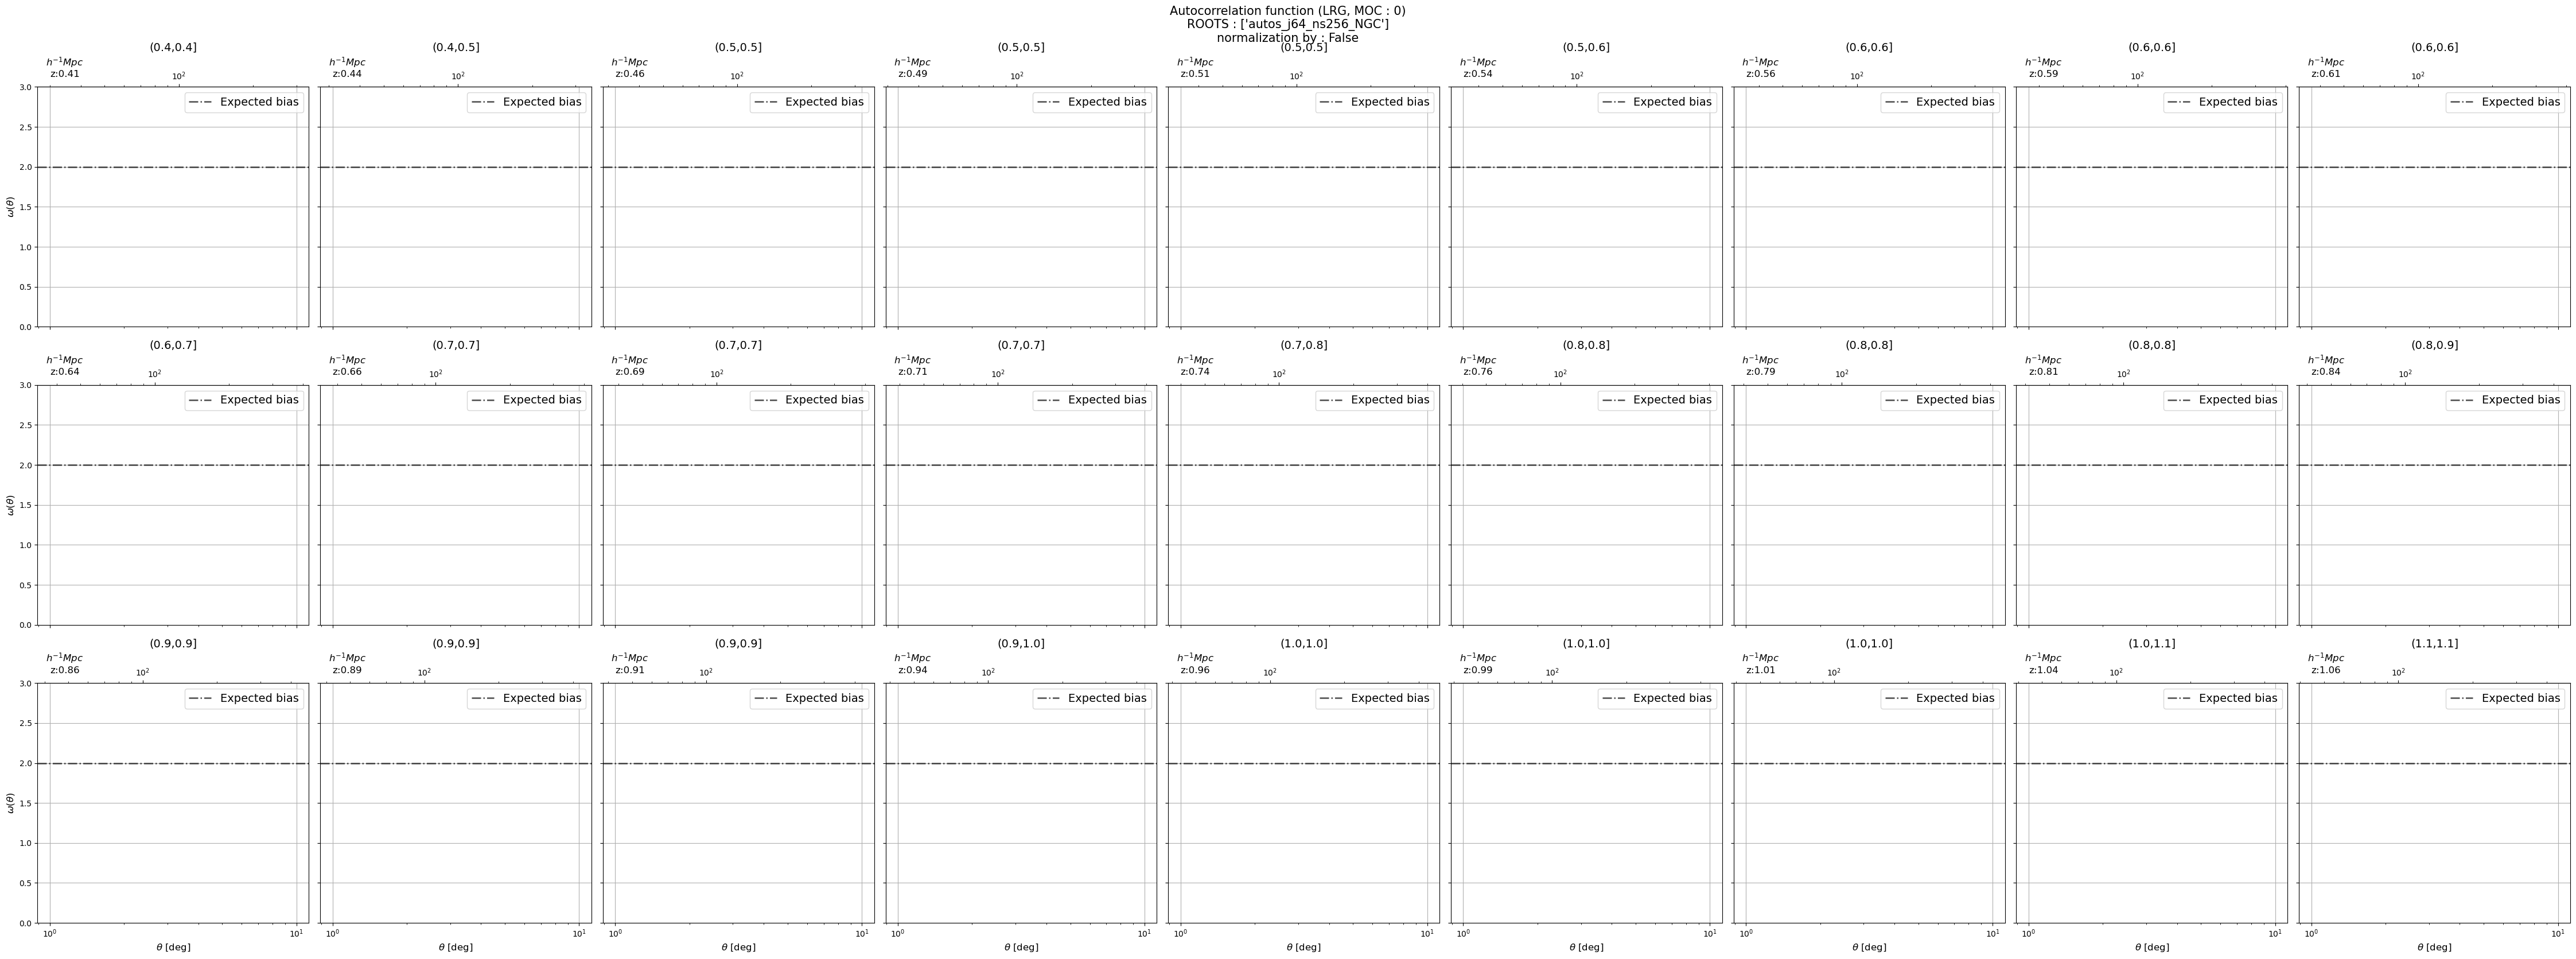

In [ ]:
ylims = (0)
nrows = 5
ncols = len(bins_tgt) // nrows
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5+2), sharex=True, sharey=True)
axs = axs.flatten()

if normalize_by_dndz:
    norm_list = dndz_list
elif normalize_by_wDM:
    norm_list = np.array(wDM_list)
else:
    norm_list = np.array([1] * len(file_readers))

for ind in range(1, len(bins_tgt)):
    mid_z = (bins_tgt[ind-1] + bins_tgt[ind]) / 2
    tohMpc = lambda theta, z=mid_z: ct.arcsec2hMpc(theta * 3600, z=z)
    toArcsec = lambda x, z=mid_z: ct.hMpc2arcsec(x, z=z) / 3600
    try:
        ax = axs[ind-1]
    except IndexError:
        print(f'No ax for {ind}')
        break


    if normalize_by_wDM:
        norm_tgt = norm_list[:, ind-1]
    elif normalize_by_dndz:
        norm_tgt = norm_list[ind-1]
    else:
        norm_tgt = norm_list

    if ind == 0:
        continue

    for i, (fr, label, color, ls, mark, show_flag, norm) in enumerate(
        zip(file_readers, plot_labels, colors, linestyles, markers, compare_flags, norm_tgt)
    ):
        if not show_flag:
            continue

        try:
            cov_result = TwoPointCorrelationFunction.load(
                fr.get_file(ind, ind, tgt, tgt, moc_idx)
            )
            if rebin > 1:
                cov_result.rebin(rebin)
        except FileNotFoundError:
            compare_flags[i] = False
            continue

        try:
            cov = cov_result.cov()
            jackerr = np.sqrt(np.diag(cov))
        except AttributeError:
            nocov = True
            jackerr = np.zeros_like(cov_result.corr)

        
        sepm = cov_result.sep if sepmult else 1

        if normalize_by_wDM:
            norm_val = norm(cov_result.sep)
        else:
            norm_val = norm

        ax.plot(
            cov_result.sep,
            sepm * np.sqrt(cov_result.corr / norm_val), 
            mark,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {label}'
        )
        ax.fill_between(
            cov_result.sep,
            sepm * np.sqrt((cov_result.corr - jackerr) / norm_val),
            sepm * np.sqrt((cov_result.corr + jackerr) / norm_val),
            color=color,
            alpha=0.3
        )

    # Axes & formatting
    if ind > (nrows - 1) * ncols:
        ax.set_xlabel(r'$\theta$ [deg]' if mode == 'theta' else r'$r_p$ [Mpc/h]', fontsize=12)
    if ind == 1 or ind == ncols + 1 or ind == 2 * ncols + 1:
        if mode == 'theta':
            ylabel = r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$'
        else:
            ylabel = r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$'
        if normalize_by_dndz:
            ylabel += r'/(dN/dz)'
        if normalize_by_wDM:
            ylabel = r'$b=\sqrt{w(\theta)/w_{DM}(z)}$'
        ax.set_ylabel(ylabel, fontsize=12)

    ax.set_xscale('log')
    ax.axhline(val_hline, color='k', linestyle='-.', lw=1.8, alpha=0.7, label='Expected bias')
    ax.set_title(f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}]', fontsize=14)
    ax.grid()

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n', fontsize=12)
    secax.xaxis.set_label_coords(0.1, 0)
    ax.legend(loc='upper right', fontsize=14)
    ax.set_ylim(*ylims)

# If last panel is not used (e.g. LRG), clean it up
if tgt == 'LRG' and len(axs) > len(bins_tgt)-1:
    fig.delaxes(axs[-1])

fig.suptitle(
    f'Autocorrelation function ({tgt}, MOC : {moc_idx})' 
    f'\nROOTS : {[Path(fr.ROOT).stem for fr in file_readers]}\n'
    f'normalization by : {normalize_by_dndz}',
    fontsize=15
)
fig.tight_layout()


In [90]:
## settings for simple autocorrelation plot
#file_reader_autos = [
#    cf.CorrFileReader('../auto/auto_allsky_ELG_nonKP_FKP'),
#    cf.CorrFileReader('../auto/auto_allsky_ELG_PIP'),
#    cf.CorrFileReader('../auto/auto_allsky_ELG_PIP_simsv5'),
#]
dicts_files = {
    f'{tgt} "HSC" ' : '../results/autos_j64_ns256_zbin', #auto12_nonKP_FKP
    #f'{tgt} sims v5' : '../auto/small_hsc_j_v5/',
    #f'{tgt} sims v5': '../auto/auto4_sims_v5/'
}
file_reader_autos = [cf.CorrFileReader(d) for d in dicts_files.values()]
labels = list(dicts_files.keys())
tgt = 'HSC'
bins_tgt = file_reader_autos[0].get_bins(tgt)
rebin = 2

show_flags = [True, True, True]
ylims = (-0.3, 0.3)
nrows = 3
ncols = len(bins_tgt) // nrows
markers = ['v', '+', '*', '^']
linestyles = ['-', '-.', '--', ':']
viridis = plt.get_cmap('viridis')
colors = [
    viridis(i/len(file_reader_autos)) for i in range(len(file_reader_autos))
    ]

In [93]:
cov_result = TwoPointCorrelationFunction.load(
                file_reader_autos[0].get_file(2, 2, tgt, tgt, 1)
            )

In [108]:
[cv for cv in dir(cov_result) if '_' not in cv]

['D1D2',
 'D1R2',
 'R1D2',
 'R1R2',
 'XX',
 'copy',
 'corr',
 'deepcopy',
 'edges',
 'load',
 'logger',
 'mode',
 'mpicomm',
 'name',
 'ndim',
 'normalize',
 'plot',
 'rebin',
 'requires',
 'run',
 'save',
 'select',
 'sep',
 'sepavg',
 'seps',
 'shape',
 'slice',
 'sum',
 'wrap']

In [116]:
cov_result.D1D2.size2

4941330

In [149]:
import src.statistics.results_methods as resm
importlib.reload(resm)
w = resm.single_bin_corr(cov_result, method='davis-peebles')

In [150]:
w

-0.6818833401203953

In [114]:
dir(cov_result.D1D2.size1)

['__abs__',
 '__add__',
 '__and__',
 '__bool__',
 '__ceil__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floor__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__le__',
 '__lshift__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rfloordiv__',
 '__rlshift__',
 '__rmod__',
 '__rmul__',
 '__ror__',
 '__round__',
 '__rpow__',
 '__rrshift__',
 '__rshift__',
 '__rsub__',
 '__rtruediv__',
 '__rxor__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__truediv__',
 '__trunc__',
 '__xor__',
 'as_integer_ratio',
 'bit_count',
 'bit_length',
 'conjugate',
 'denominator',
 'from_bytes',
 'imag',
 'numerator',
 '

In [111]:
cov_result.D1D2
cov_result.D1R2
print(cov_result.R1D2.sep)
cov_result.R1R2.sep

[0.00370199 0.00449554 0.00545919 0.00662939 0.00805019 0.00977568
 0.01187122 0.01441546 0.01750508 0.02125718 0.02581306 0.03134567
 0.03806355 0.04622169 0.05612822 0.06815965 0.08276793 0.10050761
 0.12205301 0.14821607 0.17998417 0.21856241 0.26540991 0.32228546
 0.39134468 0.47520431 0.57700407 0.70059826 0.85065133 1.03282011
 1.25392412 1.52212977]


array([0.003702  , 0.00449556, 0.00545908, 0.00662919, 0.00805014,
       0.0097756 , 0.0118709 , 0.01441536, 0.01750492, 0.02125694,
       0.02581281, 0.03134522, 0.03806325, 0.04622127, 0.05612833,
       0.06816155, 0.08277066, 0.10050991, 0.12205452, 0.14821724,
       0.17998719, 0.21856723, 0.26541362, 0.32228515, 0.39134463,
       0.47520506, 0.57700703, 0.70059582, 0.85064423, 1.03281985,
       1.25392813, 1.52215468])

In [101]:
cov_result.D1D2.ncounts

array([     1987786,      2826572,      4042248,      5798976,
            8336990,     12026200,     17358460,     25085802,
           36331722,     52626640,     76270518,    110627164,
          160394392,    232595574,    336950474,    488561480,
          708443260,   1026016732,   1484770220,   2156902874,
         3138928034,   4566492694,   6632159864,   9629981990,
        13957769694,  20174119500,  29028879660,  41486575820,
        58841836674,  82708992848, 114830963746, 156188470656])

In [98]:
dir(cov_result.D1D2)

['__add__',
 '__class__',
 '__copy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_get_default_seps',
 '_mpi_decompose',
 '_set_bin_type',
 '_set_boxsize',
 '_set_compute_sepsavg',
 '_set_default_seps',
 '_set_edges',
 '_set_los',
 '_set_mode',
 '_set_nthreads',
 '_set_positions',
 '_set_reversible',
 '_set_selection',
 '_set_weights',
 '_set_zeros',
 '_sum_auto_weights',
 'attrs',
 'autocorr',
 'bin_type',
 'boxsize',
 'compute_sepavg',
 'compute_sepsavg',
 'concatenate_x',
 'copy',
 'cos_twopoint_weights',
 'deepcopy',
 'dtype',
 'edges',
 'from_state',
 'is_reversible',
 'load',
 'log_cr

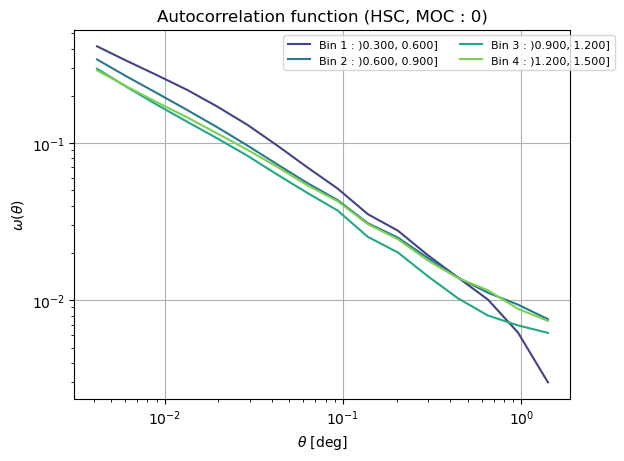

In [92]:
bins_tgt = file_reader_autos[0].get_bins(tgt)
for i in range(1, len(bins_tgt)):
    cov_result = TwoPointCorrelationFunction.load(
                file_reader_autos[0].get_file(i, i, tgt, tgt, 1)
            )
    cov_result.rebin(rebin)
    plt.plot(cov_result.sep, cov_result.corr, label=f'Bin {i} : ){bins_tgt[i-1]:.3f}, {bins_tgt[i]:.3f}]', color=viridis(i/len(bins_tgt)))
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\omega(\theta)$')
plt.title(f'Autocorrelation function ({tgt}, MOC : {moc_idx})')
plt.legend(fontsize=8, ncols=2, bbox_to_anchor=(1.1, 1))
plt.grid()
plt.xscale('log')
plt.yscale('log')

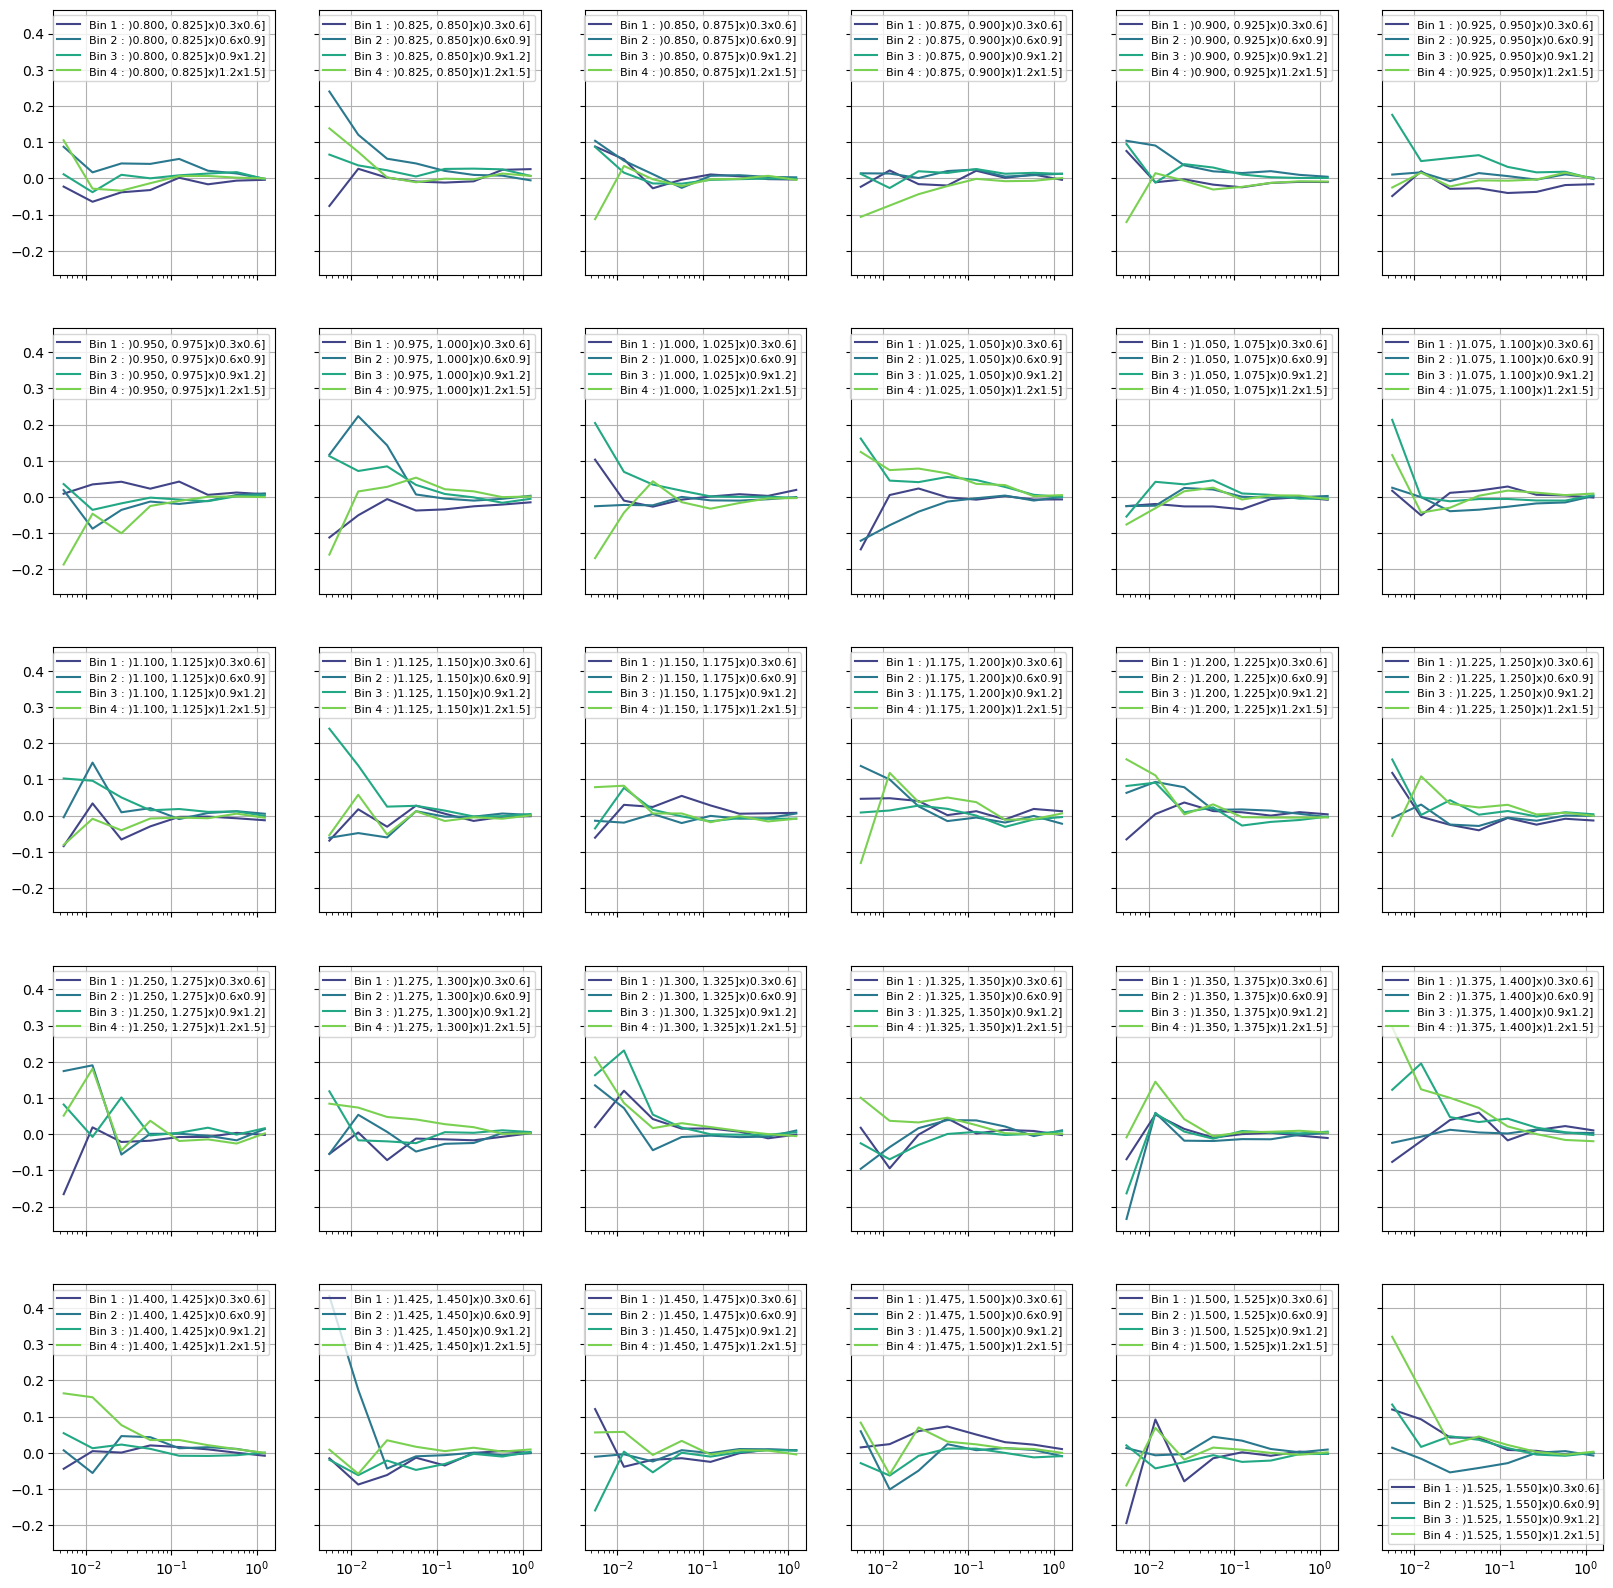

In [87]:
file_readers_cross = [
    cf.CorrFileReader('../results/cross_j64_ns256_zbin'),
]
tgt = 'ELGnotqso'
bins_tgt = file_readers_cross[0].get_bins(tgt)
bins_hsc = file_readers_cross[0].get_bins('HSC')

fig, axs = plt.subplots(5, len(bins_tgt)//5, figsize=(20, 20), sharex=True, sharey=True)
axs = axs.flatten()
for j in range(1, len(bins_tgt)):
    if j > len(axs):
        break
    ax = axs[j-1]
    for i in range(1, len(bins_hsc)):
        cov_result = TwoPointCorrelationFunction.load(
                    file_readers_cross[0].get_file(j, i, tgt, 'HSC', 0)
                )
        cov_result.rebin(4)
        ax.plot(
            cov_result.sep, 
            cov_result.corr, 
            label=f'Bin {i} : ){bins_tgt[j-1]:.3f}, {bins_tgt[j]:.3f}]x){bins_hsc[i-1]:.1f}x{bins_hsc[i]:.1f}]', 
            color=viridis(i/len(bins_hsc))
            )
        ax.legend(fontsize=8)
    #ax.set_xlabel(r'$\theta$ [deg]')
    #ax.set_ylabel(r'$\omega(\theta)$')
    #ax.set_title(f'Autocorrelation function ({tgt}, MOC : {moc_idx})')
    #ax.legend(fontsize=8, ncols=2, bbox_to_anchor=(1.1, 1))
    ax.grid()
    ax.set_xscale('log')
    #ax.set_yscale('log')

In [ ]:
cov_result.concatenate_xcorr()

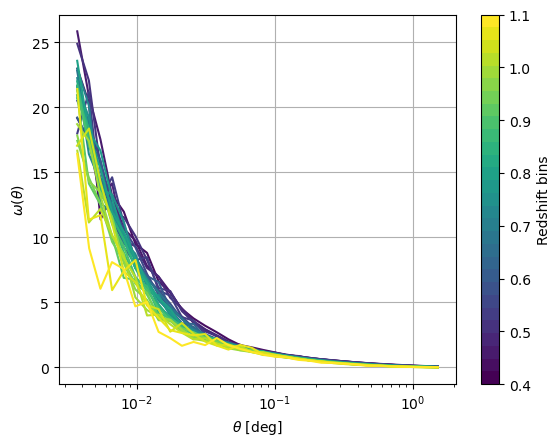

In [ ]:
tgt = 'ELGnotqso'
bins_tgt = file_reader_autos[0].get_bins(tgt)
cmap = plt.get_cmap('viridis', len(bins_tgt))
norm = mcolors.Normalize(vmin=min(bins_tgt), vmax=max(bins_tgt))
fig, ax = plt.subplots()

for i in range(1, len(bins_tgt)):
    #print(f'Bin {i} : {bins_tgt[i-1]:.3f}, {bins_tgt[i]:.3f}]')
    cov_result = TwoPointCorrelationFunction.load(
                file_reader_autos[0].get_file(i, i, tgt, tgt, 1)
            )
    ax.plot(
        cov_result.sep, 
        cov_result.corr, 
        label=f'Bin {i} : ){bins_tgt[i-1]:.3f}, {bins_tgt[i]:.3f}]', 
        color=cmap(norm(bins_tgt[i]))
        )
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(bins_tgt)
#sm.set_array([])  # Only needed for colorbar
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Redshift bins')

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\omega(\theta)$')
ax.set_xscale('log')
ax.grid()
#ax.set_yscale('log')

/tmp/ipykernel_481280/3013026155.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=14)


IndexError: index 27 is out of bounds for axis 0 with size 27

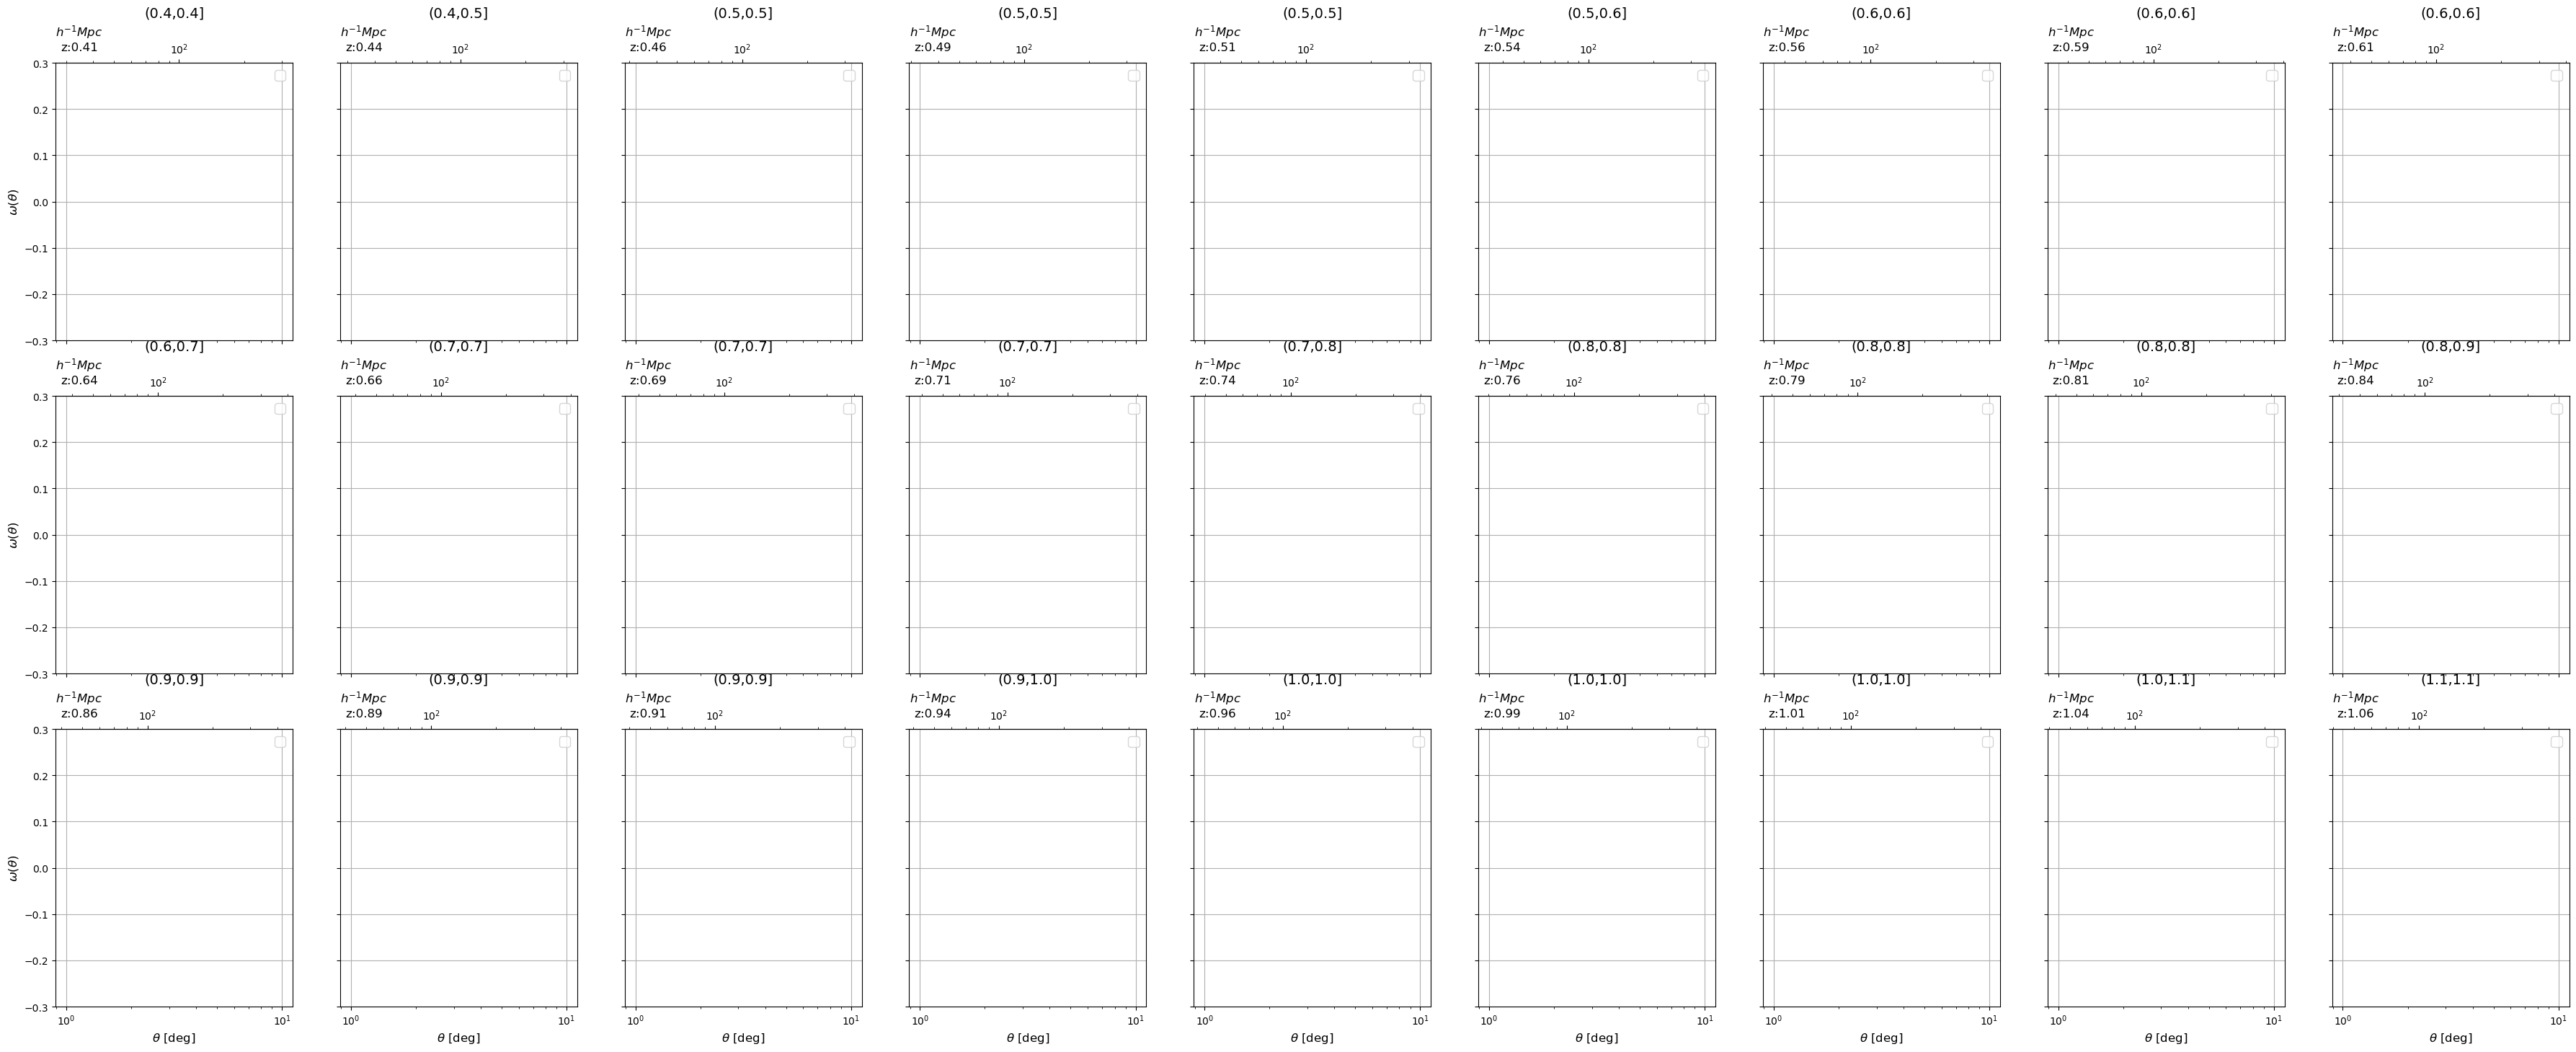

In [15]:
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5+2), sharex=True, sharey=True)
axs = axs.flatten()

for ind in range(1, len(bins_tgt)):
    mid_z = (bins_tgt[ind-1] + bins_tgt[ind]) / 2
    tohMpc = lambda theta, z=mid_z: ct.arcsec2hMpc(theta * 3600, z=z)
    toArcsec = lambda x, z=mid_z: ct.hMpc2arcsec(x, z=z) / 3600
    ax = axs[ind-1]

    for i, (fr, label, color, ls, mark, show) in enumerate(
        zip(file_reader_autos, labels, colors, linestyles, markers, show_flags)
    ):
        if not show:
            continue

        try:
            cov_result = TwoPointCorrelationFunction.load(
                fr.get_file(ind, ind, tgt, tgt, moc_idx)
            )
            print(f'File: {fr.get_file(ind, ind, tgt, tgt, moc_idx)}')
            if rebin > 1:
                cov_result.rebin(rebin)
        except FileNotFoundError:
            continue

        try:
            cov = cov_result.cov()
            jackerr = np.sqrt(np.diag(cov))
        except AttributeError:
            nocov = True
            jackerr = np.zeros_like(cov_result.corr)
        
        sepm = cov_result.sep if sepmult else 1
        ax.plot(
            cov_result.sep,
            sepm * (cov_result.corr), 
            mark,
            color=color,
            linestyle=ls,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {label}'
        )
        ax.fill_between(
            cov_result.sep,
            sepm * (cov_result.corr - jackerr),
            sepm * (cov_result.corr + jackerr),
            color=color,
            alpha=0.3
        )

    # Axes & formatting
    if ind > (nrows - 1) * ncols:
        ax.set_xlabel(r'$\theta$ [deg]' if mode == 'theta' else r'$r_p$ [Mpc/h]', fontsize=12)
    if ind == 1 or ind == ncols + 1 or ind == 2 * ncols + 1:
        if mode == 'theta':
            ylabel = r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$'
        else:
            ylabel = r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$'
        if normalize_by_dndz:
            ylabel += r'/(dN/dz)'
        if normalize_by_wDM:
            ylabel = r'$b=\sqrt{w(\theta)/w_{DM}(z)}$'
        ax.set_ylabel(ylabel, fontsize=12)

    ax.set_xscale('log')
    ax.set_title(f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}]', fontsize=14)
    ax.grid()

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n', fontsize=12)
    secax.xaxis.set_label_coords(0.1, 0)
    ax.legend(loc='upper right', fontsize=14)
    ax.set_ylim(*ylims)

# If last panel is not used (e.g. LRG), clean it up
if tgt == 'LRG' or tgt == 'ELGnotqso':
    fig.delaxes(axs[-1])

fig.suptitle(
    f'Autocorrelation function ({tgt}, MOC : {moc_idx})' 
    f'\nROOTS : {[Path(fr.ROOT).stem for fr in file_readers]}\n'
    f'normalization by : {normalize_by_dndz}',
    fontsize=15
)
fig.tight_layout()

In [44]:
import math
logbins = np.logspace(math.log(1, 10), math.log(250, 10), 26, base=10)/60

In [ ]:
print(np.logspace(math.log(0.2, 10), math.log(200, 10), 26, base=10)/60)
print(np.logspace(math.log(2.5, 10), math.log(250, 10), 21, base=10)/60)

[0.00833333 0.01059013 0.01345809 0.01710275 0.02173443 0.02762045
 0.03510049 0.04460623 0.05668628 0.07203779 0.09154671 0.11633895
 0.14784531 0.18788407 0.23876593 0.30342737 0.38560011 0.49002648
 0.6227331  0.79137868 1.00569606 1.27805383 1.62417023 2.06402021
 2.62298825 3.33333333]
[0.04166667 0.05245523 0.06603722 0.08313593 0.10466193 0.13176157
 0.16587799 0.20882801 0.26289889 0.3309701  0.41666667 0.52455225
 0.66037216 0.8313593  1.04661935 1.31761569 1.65877988 2.08828014
 2.62898894 3.30970098 4.16666667]


In [59]:
import src.statistics.cosmotools as ct 
import math
print(
    [
        float(f'{a:.3f}')
        for a in ct.arcsec2hMpc(np.logspace(math.log(0.2, 10), math.log(200, 10), 21, base=10)*60, 1)
    ]
    )

[0.146, 0.206, 0.291, 0.411, 0.581, 0.821, 1.16, 1.638, 2.314, 3.268, 4.617, 6.521, 9.211, 13.011, 18.379, 25.961, 36.67, 51.798, 73.167, 103.351, 145.987]


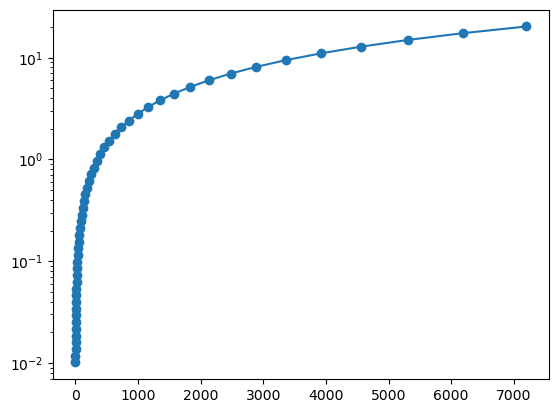

In [ ]:

bins_angular = 3600*np.logspace(
        np.log(0.001), 
        np.log(2), 
        51,
        base=np.e
    )
bins_mpc = ct.arcsec2hMpc(bins_angular, z=0.1)
plt.plot(bins_angular, bins_mpc, 'o-')
plt.yscale('log')

In [80]:
file_reader = cf.CorrFileReader('../auto/auto_allsky_ELG_PIP_rp_nojk_withmoc')

In [84]:
tgt = 'ELGnotqso'
res = TwoPointEstimator.load(file_reader.get_file(1, 1, tgt, tgt, moc_idx))

array([0.00016971,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan])

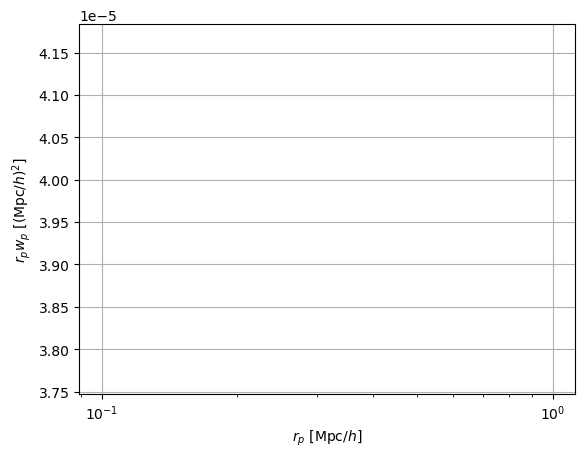

In [91]:
res.plot()
plt.xscale('log')
res.corr

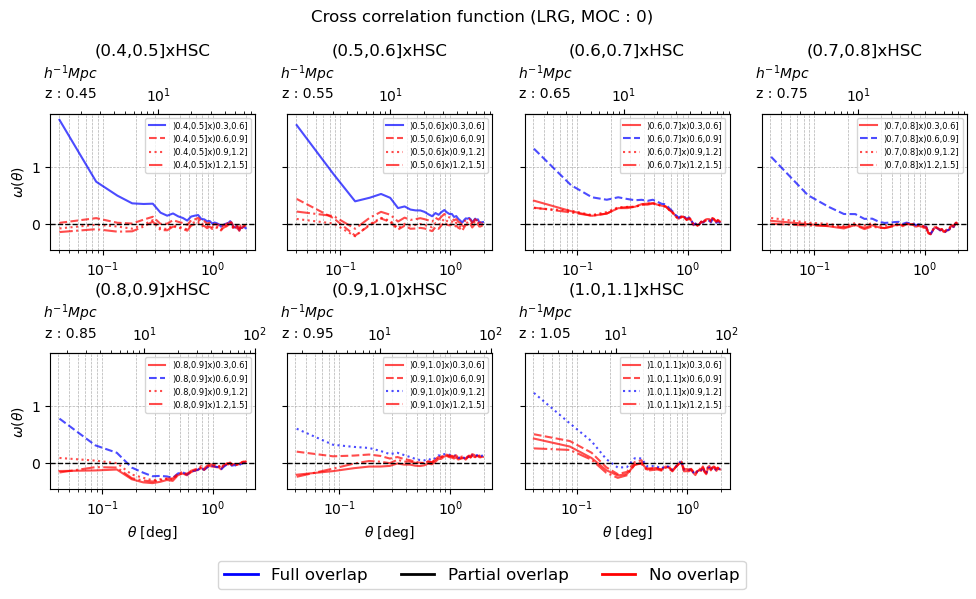

In [ ]:
file_reader = cf.CorrFileReader('../crosscorr/run19/')
tgt = 'LRG'
bhsc = file_reader.get_bins('HSC')
btgt = file_reader.get_bins(tgt)
moc_idx = 0

cmap = plt.get_cmap('rainbow')
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(10, 6))

axs = axs.flatten()
if tgt == 'LRG':
    fig.delaxes(axs[-1])
axs = axs[:len(btgt)-1]

for i, ax in enumerate(axs, start=1):
    for j in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(
            file_reader.get_file(i, j, moc_idx, tgt)
        )
        
        # Define bin edges
        btgt_min, btgt_max = btgt[i-1], btgt[i]
        bhsc_min, bhsc_max = bhsc[j-1], bhsc[j]

        # Check overlap conditions
        if bhsc_min <= btgt_min and bhsc_max >= btgt_max:
            color = 'blue'  # Full overlap
        elif bhsc_max <= btgt_min or bhsc_min >= btgt_max:
            color = 'red'   # No overlap
        else:
            color = 'black' # Partial overlap
        ls = '-' 
        if j == 2:
            ls = '--'
        if j == 3:
            ls = ':'
        if j == 4:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=color,
            )
        if i > 4:
            ax.set_xlabel(r'$\theta$ [deg]')
        if i == 1 or i == 5:
            ax.set_ylabel(r'$\omega(\theta)$')

    ax.grid(True, which='both', linestyle='--', lw=0.5)
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({btgt[i-1]:.1f},{btgt[i]:.1f}]xHSC', fontsize=12)
    ax.legend(loc='upper right', fontsize=6)

    mid_z = (btgt[i-1] + btgt[i]) / 2
    tohMpc = lambda x, z=mid_z: ct.arcsec2hMpc(x * 3600, z=z)
    toArcsec = lambda theta, z=mid_z: ct.hMpc2arcsec(theta, z=z) / 3600

    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz : {mid_z:.2f}\n')
    secax.xaxis.set_label_coords(0.1, 1.1)
            
fig.suptitle(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)
fig.tight_layout()

# overlap types
custom_lines = [
    mlines.Line2D([0], [0], color='blue', lw=2),
    mlines.Line2D([0], [0], color='black', lw=2),
    mlines.Line2D([0], [0], color='red', lw=2)
    ]
fig.legend(
    custom_lines, 
    [
        'Full overlap', 
        'Partial overlap', 
        'No overlap'
        ], 
    loc='lower center', 
    ncol=3, 
    bbox_to_anchor=(0.5, 0), 
    fontsize=12
    )
plt.subplots_adjust(bottom=0.18)

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

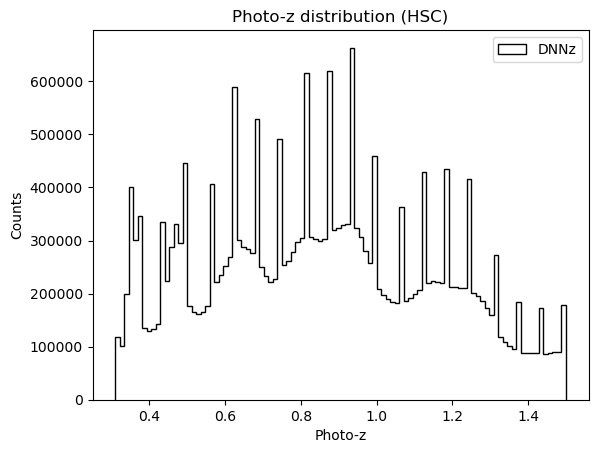

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

In [ ]:
compare_1 = True
compare_2 = True

sepmult = False
mode = 'theta' 
normalize_by_dndz = True
rebin = 2
bins_tgt = file_reader.get_bins(tgt)
ylims = (-10, 60)
nocov = False

if normalize_by_dndz:
    try:
        dndz_tgt1 = file_reader.get_dndz(tgt)
        print(f'dN/dz {plot_0}: {dndz_tgt1}')
    except ValueError:
        pass
    try:
        dndz_tgt_1 = file_reader_1.get_dndz(tgt)
        print(f'dN/dz {plot_1}: {dndz_tgt_1}')
    except ValueError:
        compare_1 = False
        pass
    try:
        dndz_tgt_2 = file_reader_2.get_dndz(tgt)
        print(f'dN/dz {plot_2}: {dndz_tgt_2}')
    except ValueError:
        compare_2 = False
        pass

nrows = 2
ncols = len(bins_tgt)//nrows
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*5+2), sharex=True, sharey=True)
plasma = plt.get_cmap('plasma')
viridis = plt.get_cmap('viridis')
axs = axs.flatten()

for ind in range(1, len(bins_tgt)):
    mid_z = (bins_tgt[ind-1] + bins_tgt[ind]) / 2

    ax = axs[ind-1]
    if ind == 0:
        continue
    try:
        cov_result = TwoPointCorrelationFunction.load(
            file_reader.get_file(ind, ind, tgt, tgt, moc_idx)
            )
        if rebin > 1:
            cov_result.rebin(rebin)
    except FileNotFoundError:
        pass
    if compare_1:
        try:
            cov_result_1 = TwoPointCorrelationFunction.load(
                file_reader_1.get_file(ind, ind, tgt, tgt, moc_idx)
                )
            if rebin > 1:
                cov_result_1.rebin(rebin)
        except FileNotFoundError:
            compare_1 = False
            pass
    if compare_2:
        try:
            cov_result_2 = TwoPointCorrelationFunction.load(
                file_reader_2.get_file(ind, ind, tgt, tgt, moc_idx)
                )
            if rebin > 1:
                cov_result_2.rebin(rebin)
        except FileNotFoundError:
            compare_2 = False
            pass

    
    # Define bin edges
    btgt_min, btgt_max = bins_tgt[ind-1], bins_tgt[ind]

    ls = '-' 
    mark = 'v'
    color = plasma(0.6)

    ls_1 = '-.'
    mark_1 = '+'
    color_1 = viridis(0.2)

    ls_2 = '--'
    mark_2 = '*'
    color_2 = viridis(0.5)

    sep = cov_result.sep
    try:
        cov = cov_result.cov()
        jackerr = np.sqrt(np.diag(cov))
    except AttributeError:
        nocov = True
        jackerr = np.zeros_like(cov_result.corr)
        pass

    normalization = 1
    if normalize_by_dndz:
        normalization = dndz_tgt1[ind-1]
        pass 
    sepm = (cov_result.sep if sepmult else 1)
    ax.fill_between(
        cov_result.sep,
        sepm*(cov_result.corr-jackerr)/normalization,
        sepm*(cov_result.corr+jackerr)/normalization,
        color=color,
        alpha=0.3
    )
    ax.plot(
        cov_result.sep,
        sepm*cov_result.corr/normalization,
        mark,
        color=color,
        linestyle=ls,
        alpha=0.8,
        label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_0}'
    )
    if compare_1:
        if normalize_by_dndz:
            normalization = dndz_tgt_1[ind-1]
        try:
            jackerr_1 = np.sqrt(np.diag(cov_result_1.cov()))
        except AttributeError:
            nocov = True
            jackerr_1 = np.zeros_like(cov_result_1.corr)
            pass
        ax.plot(
            cov_result_1.sep,
            sepm*cov_result_1.corr/normalization,
            mark_1,
            color=color_1,
            linestyle=ls_1,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_1}'
        )
        ax.fill_between(
            cov_result_1.sep,
            sepm*(cov_result_1.corr-jackerr_1)/normalization,
            sepm*(cov_result_1.corr+jackerr_1)/normalization,
            color=color_1,
            alpha=0.3
        )
    if compare_2:
        if normalize_by_dndz:
            normalization = dndz_tgt_2[ind-1]
        try:
            jackerr_2 = np.sqrt(np.diag(cov_result_2.cov()))
        except AttributeError:
            nocov = True
            jackerr_2 = np.zeros_like(cov_result_2.corr)
            pass
        ax.plot(
            cov_result_2.sep,
            sepm*cov_result_2.corr/normalization,
            mark_2,
            color=color_2,
            linestyle=ls_2,
            alpha=0.8,
            label=f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}] {plot_2}'
        )
        ax.fill_between(
            cov_result_2.sep,
            sepm*(cov_result_2.corr-jackerr_2)/normalization,
            sepm*(cov_result_2.corr+jackerr_2)/normalization,
            color=color_2,
            alpha=0.3
        )
    if ind > (nrows-1)*ncols:
        if mode == 'theta':    
            ax.set_xlabel(r'$\theta$ [deg]')
        elif mode == 'rp':
            ax.set_xlabel(r'$r_p$ [Mpc/h]')
    if ind == 1 or ind == ncols//2+1:
        if mode == 'theta':    
            ax.set_ylabel(
                r'$\omega(\theta)$' if not sepmult else r'$\theta \omega(\theta)$'
                + (r'/(dN/dz)' if normalize_by_dndz else '')
                )
        elif mode == 'rp':
            ax.set_ylabel(r'$w_p(r_p)$' if not sepmult else r'$r_p w(r_p) [(Mpc/h)^2]$')
    ax.set_xscale('log')
    ax.axhline(0, color='k', linestyle='--', lw=1)
    ax.set_title(f'({bins_tgt[ind-1]:.1f},{bins_tgt[ind]:.1f}]', fontsize=12)
    ax.grid()
    secax = ax.secondary_xaxis('top', functions=(tohMpc, toArcsec))
    secax.set_xlabel(r'$h^{-1}Mpc$' + f'\nz:{mid_z:.2f}\n')
    #secax.set_xscale('linear')
    secax.xaxis.set_label_coords(0.1, 0)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(ylims[0], ylims[1])

if tgt == 'LRG':
    fig.delaxes(axs[-1])

fig.suptitle(
    f'Autocorrelation function ({tgt}, MOC : {moc_idx})' 
    f'\nROOT : {Path(file_reader.ROOT).stem}\n'
    f'normalization by dN/dz: {normalize_by_dndz}',
)
fig.tight_layout()
            

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

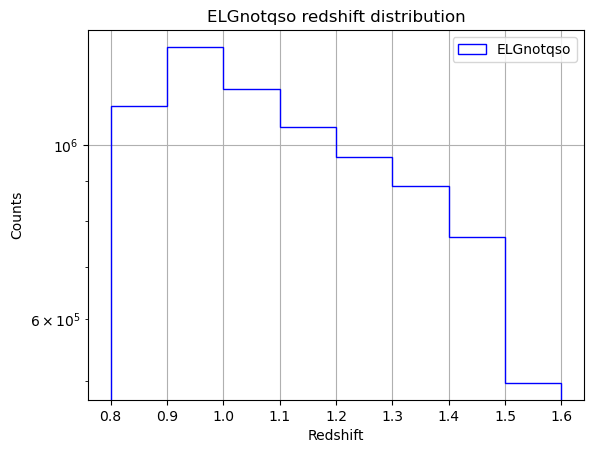

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


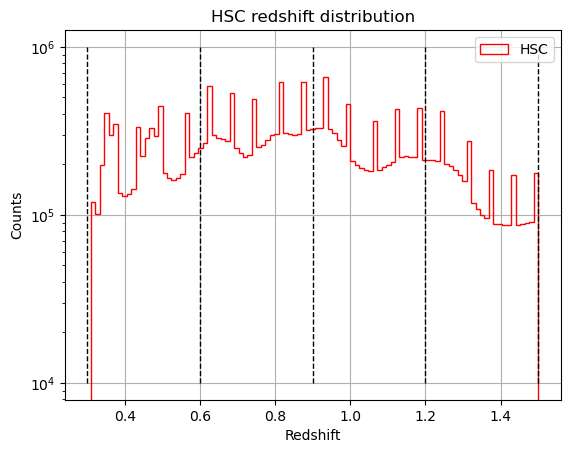

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))

In [ ]:
import src.statistics.corrfiles as cf
from astropy.table import Table
importlib.reload(cf)
file = cf.fetch_desi_files(tgt='ELGnotqso', randoms=False, weight_type='nonKP', sims=False, cap='SGC')
tbl = Table(fio.read(file))
plt.hist(tbl['WEIGHT'], bins=200, histtype='step', label='nonKP', color='blue', alpha=0.5)
plt.hist(tbl['WEIGHT_FKP'], bins=200, histtype='step', label='FKP', color='red', alpha=0.5)
plt.hist(tbl['WEIGHT_COMP'], bins=200, histtype='step', label='COMP', color='purple', alpha=0.5)
plt.hist(tbl['WEIGHT_FKP']*tbl['WEIGHT'], bins=200, histtype='step', label='nonKP FKP', color='green', alpha=0.5)
plt.hist(tbl['WEIGHT_FKP']*tbl['WEIGHT']*tbl['WEIGHT_COMP'], bins=200, histtype='step', label='nonKP FKP COMP', color='orange', alpha=0.5)
plt.xlabel('Weight')
plt.ylabel('Counts')
plt.legend()
plt.xscale('log')
plt.yscale('log')